In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Загрузка данных 
data = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

# Оставляем только нужные столбцы
data = data[['date_time', 'traffic_volume', 'holiday', 'temp']]

# Преобразование в datetime и установка в качестве индекса
data['date_time'] = pd.to_datetime(data['date_time'])
data = data.sort_values('date_time').set_index('date_time')

In [80]:
data

,traffic_volume,holiday,temp
date_time,,,
2012-10-02 09:00:00,5545,NaN,288.28
2012-10-02 10:00:00,4516,NaN,289.36
2012-10-02 11:00:00,4767,NaN,289.58
2012-10-02 12:00:00,5026,NaN,290.13
2012-10-02 13:00:00,4918,NaN,291.14
...,...,...,...
2018-09-30 19:00:00,3543,NaN,283.45
2018-09-30 20:00:00,2781,NaN,282.76
2018-09-30 21:00:00,2159,NaN,282.73


In [81]:
data['holiday'].unique()

<ArrowStringArray>
[                        nan,              'Columbus Day',
              'Veterans Day',          'Thanksgiving Day',
             'Christmas Day',             'New Years Day',
      'Washingtons Birthday',              'Memorial Day',
          'Independence Day',                'State Fair',
                 'Labor Day', 'Martin Luther King Jr Day']
Length: 12, dtype: str

In [82]:
# Если значение не NaN (т.е. там есть название праздника), ставим 1, иначе 0
data['is_holiday'] = data['holiday'].notna().astype(int)

In [83]:
# Размечаем праздник на весь день (если хоть один час помечен как праздник)
data['is_holiday'] = data.groupby(data.index.date)['is_holiday'].transform('max')

In [84]:
# Удаляем исходный столбец с названиями
data = data.drop(columns=['holiday'])

In [85]:
data[data['is_holiday'] == 1]

,traffic_volume,temp,is_holiday
date_time,,,
2012-10-08 00:00:00,455,273.08,1
2012-10-08 01:00:00,336,272.62,1
2012-10-08 02:00:00,265,271.78,1
2012-10-08 03:00:00,314,271.05,1
2012-10-08 04:00:00,779,270.63,1
...,...,...,...
2018-09-03 21:00:00,2081,294.80,1
2018-09-03 22:00:00,1588,294.49,1
2018-09-03 22:00:00,1588,294.49,1


In [87]:
# 1. Удаление дубликатов по индексу (времени)
data = data[~data.index.duplicated(keep='first')]

# 2. Выравнивание временных интервалов (каждый час)
full_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='h')
data = data.reindex(full_range)

# 3. Интерполяция пропусков для числовых переменных
data['traffic_volume'] = data['traffic_volume'].interpolate(method='linear')
data['temp'] = data['temp'].interpolate(method='linear')

In [90]:
data

,traffic_volume,temp,is_holiday
2012-10-02 09:00:00,5545.0,288.28,0.0
2012-10-02 10:00:00,4516.0,289.36,0.0
2012-10-02 11:00:00,4767.0,289.58,0.0
2012-10-02 12:00:00,5026.0,290.13,0.0
2012-10-02 13:00:00,4918.0,291.14,0.0
...,...,...,...
2018-09-30 19:00:00,3543.0,283.45,0.0
2018-09-30 20:00:00,2781.0,282.76,0.0
2018-09-30 21:00:00,2159.0,282.73,0.0
2018-09-30 22:00:00,1450.0,282.09,0.0


In [92]:
HORIZON = 24 * 7  # Прогноз на 1 неделю (168 часов)
TEST_SIZE = 24 * 14 # Откладываем 2 недели (336 часов)

# Разделение данных
train_full = data.iloc[:-TEST_SIZE]
test = data.iloc[-TEST_SIZE:]

# Оставляем для обучения только последний год данных
cutoff_date = train_full.index.max() - pd.Timedelta(days=365)
train = train_full.loc[train_full.index >= cutoff_date]

# Функция для генерации признаков из даты
def create_features(data):
    data = data.copy()
    data['hour'] = data.index.hour
    data['weekday'] = data.index.weekday
    data['month'] = data.index.month
    return data

train = create_features(train)
test = create_features(test)

In [95]:
train

,traffic_volume,temp,is_holiday,hour,weekday,month
2017-09-16 23:00:00,2540.0,288.41,0.0,23,5,9
2017-09-17 00:00:00,1739.0,288.02,0.0,0,6,9
2017-09-17 01:00:00,951.0,287.44,0.0,1,6,9
2017-09-17 02:00:00,662.0,286.72,0.0,2,6,9
2017-09-17 03:00:00,378.0,285.88,0.0,3,6,9
...,...,...,...,...,...,...
2018-09-16 19:00:00,3400.0,303.02,0.0,19,6,9
2018-09-16 20:00:00,3092.0,300.78,0.0,20,6,9
2018-09-16 21:00:00,2623.0,298.90,0.0,21,6,9
2018-09-16 22:00:00,1725.0,297.85,0.0,22,6,9


In [96]:
# Считаем средние значения по дню недели и часу
baseline_means = train.groupby(['weekday', 'hour'])['traffic_volume'].mean()

# Делаем прогноз на тестовую выборку
test['baseline_pred'] = test.apply(
    lambda row: baseline_means.get((row['weekday'], row['hour']), np.nan), axis=1
)

# Оцениваем только на горизонте 1 неделя (168 часов)
y_true_test = test['traffic_volume'].iloc[:HORIZON]
y_pred_baseline = test['baseline_pred'].iloc[:HORIZON]

mae_baseline = mean_absolute_error(y_true_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_true_test, y_pred_baseline))

print(f"Baseline MAE: {mae_baseline:.2f}, RMSE: {rmse_baseline:.2f}")

Baseline MAE: 211.21, RMSE: 298.39


Прогнозируем температуру...
Обучаем SARIMA... Это может занять 5-15 минут из-за сезонности 168.
                                      SARIMAX Results                                      
Dep. Variable:                      traffic_volume   No. Observations:                 8761
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 168)   Log Likelihood              -60455.331
Date:                             Mon, 01 Jun 2026   AIC                         120922.662
Time:                                     14:24:05   BIC                         120965.013
Sample:                                 09-16-2017   HQIC                        120937.107
                                      - 09-16-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp      

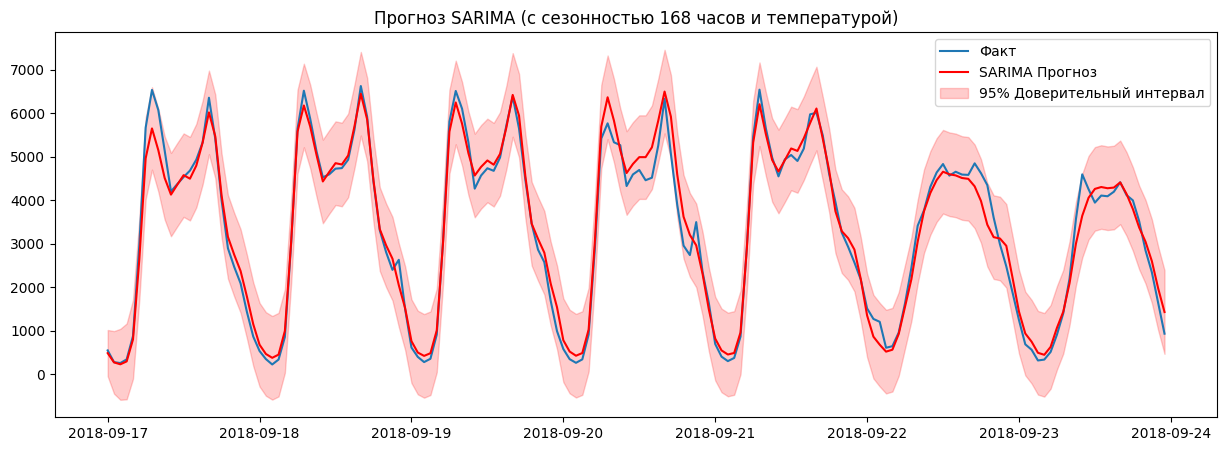

In [99]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Подготавливаем целевую переменную (с явным указанием частоты 'h')
y_train = train['traffic_volume'].asfreq('h')
y_test = test['traffic_volume'].asfreq('h').iloc[:HORIZON]

# 2. Прогнозируем температуру на период теста с помощью ETS
# Используем train_full, так как ETS нужна длинная история для сезонности
print("Прогнозируем температуру...")
temp_ets_model = ExponentialSmoothing(
    train_full['temp'].asfreq('h'), 
    trend='add', 
    seasonal='add', 
    seasonal_periods=24
).fit()
temp_forecast_values = temp_ets_model.forecast(TEST_SIZE)

# 3. Формируем экзогенные признаки (температура) для трейна и теста
exog_train = train[['temp']].asfreq('h')

# Создаем датафрейм с прогнозом температуры для теста
exog_test = pd.DataFrame({
    'temp': temp_forecast_values.iloc[:HORIZON].values
}, index=y_test.index)

# 4. Строим SARIMA (SARIMAX)
print("Обучаем SARIMA... Это может занять 5-15 минут из-за сезонности 168.")
sarima_model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1, 0, 1),              
    seasonal_order=(1, 0, 1, 168), # 24*7 = 168
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())

# 5. Прогноз на 1 неделю вперёд
forecast_obj = sarima_results.get_forecast(steps=HORIZON, exog=exog_test)
y_pred_sarima = forecast_obj.predicted_mean
ci_sarima = forecast_obj.conf_int(alpha=0.05)

# 6. Оценка качества
mae_sarima = mean_absolute_error(y_test, y_pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(y_test, y_pred_sarima))

print(f"\nSARIMA MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}")
print(f"Для сравнения Baseline MAE: 211.21")

# 7. Визуализация
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test, label='Факт')
plt.plot(y_test.index, y_pred_sarima, label='SARIMA Прогноз', color='red')
plt.fill_between(ci_sarima.index, 
                 ci_sarima.iloc[:, 0], 
                 ci_sarima.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% Доверительный интервал')
plt.title('Прогноз SARIMA (с сезонностью 168 часов и температурой)')
plt.legend()
plt.show()

Обновляем модель тестовыми данными...
Прогнозируем температуру в будущее...
Строим прогноз в будущее...


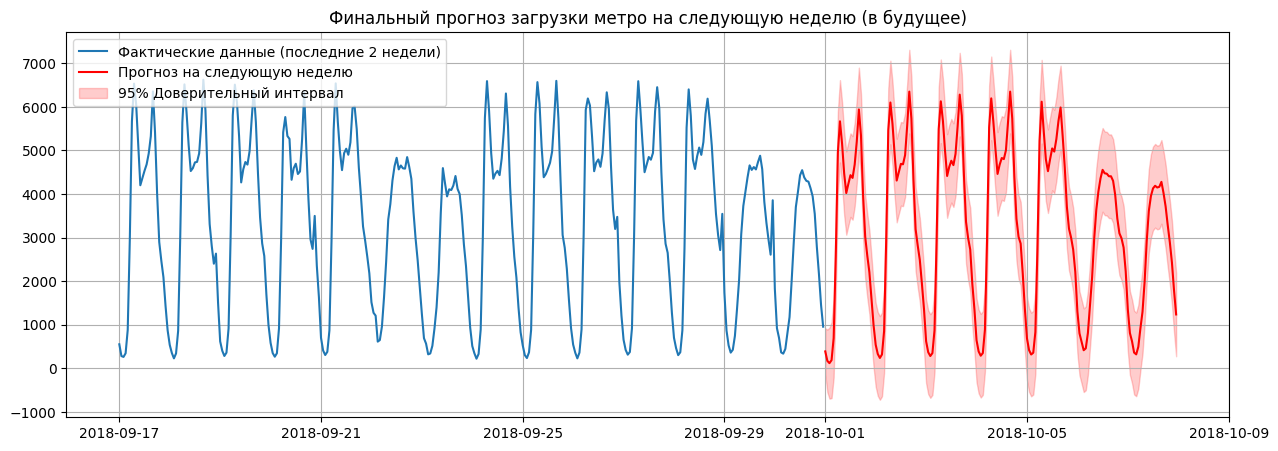


Прогноз на первые 5 часов следующей недели:
2018-10-01 00:00:00    386.557549
2018-10-01 01:00:00    169.461046
2018-10-01 02:00:00    116.735757
2018-10-01 03:00:00    185.403783
2018-10-01 04:00:00    693.387036
Freq: h, Name: predicted_mean, dtype: float64


In [ ]:
# 1. Обновляем модель, добавив в нее реальные данные за тестовые 2 недели
# (чтобы модель "увидела" актуальный конец датасета)
print("Обновляем модель тестовыми данными...")
y_test_full = test['traffic_volume'].asfreq('h')
exog_test_full = test[['temp']].asfreq('h').rename(columns={'temp': 'temp'}) # реальная температура за тест

sarima_results_updated = sarima_results.append(y_test_full, exog=exog_test_full)

# 2. Прогнозируем температуру на "настоящую" следующую неделю (за пределы датасета)
print("Прогнозируем температуру в будущее...")
temp_full = data['temp'].asfreq('h') # Берем ВСЮ историю температур
ets_full_model = ExponentialSmoothing(
    temp_full, trend='add', seasonal='add', seasonal_periods=24
).fit()
future_temp_forecast = ets_full_model.forecast(HORIZON)

# Формируем экзогенный признак для будущего
exog_future = pd.DataFrame({
    'temp': future_temp_forecast.values
}, index=future_temp_forecast.index)

# 3. Строим финальный прогноз на неизвестную следующую неделю
print("Строим прогноз в будущее...")
final_forecast = sarima_results_updated.get_forecast(steps=HORIZON, exog=exog_future)
final_pred = final_forecast.predicted_mean
final_ci = final_forecast.conf_int(alpha=0.05) # 95% доверительный интервал

# 4. Визуализация: последние 2 недели факта + прогноз на следующую неделю
plt.figure(figsize=(15, 5))

# Рисуем конец реальных данных (используем уже готовую переменную из этого блока)
plt.plot(y_test_full, label='Фактические данные (последние 2 недели)')

# Рисуем прогноз
plt.plot(final_pred.index, final_pred, label='Прогноз на следующую неделю', color='red')
plt.fill_between(final_ci.index, 
                 final_ci.iloc[:, 0], 
                 final_ci.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% Доверительный интервал')

plt.title('Финальный прогноз загрузки метро на следующую неделю (в будущее)')
plt.legend()
plt.grid(True)
plt.show()

print("\nПрогноз на первые 5 часов следующей недели:")
print(final_pred.head())